## Droplet dynamics - Laminar to turbulent flow 

### References: 
#### 1. Binary-fluid turbulence: Signatures of multifractal droplet dynamics and dissipation reduction
#### 2. Spatiotemporal dynamics in two-dimensional Kolmogorov flow over large domains


Reference: Binary-fluid turbulence: Signatures of multifractal droplet dynamics and dissipation reduction
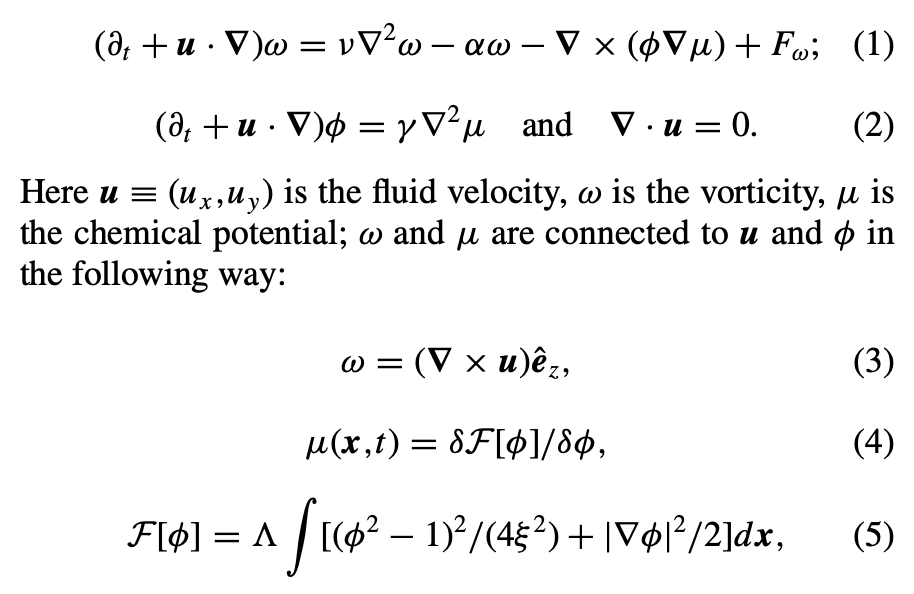
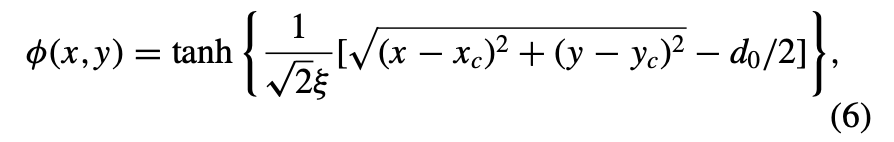

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.linalg as la
import matplotlib.animation as animation
from skimage import measure

from pathlib import Path
import json
from datetime import datetime
from IPython.display import HTML


In [2]:
## Grid has N^2 points (2D)
## Periodic domain (D = l^d), l = length of the side of d-dimensional hypercubic domain

# Domain 
L_x = 2*np.pi
L_y = 2*np.pi
N_x = 256
N_y = 256

# 2D periodic grid
del_x = L_x/N_x
del_y = L_y/N_y
x_j = np.arange(N_x) * del_x
y_j = np.arange(N_y) * del_y
X, Y = np.meshgrid(x_j, y_j, indexing='xy')

# Wrapped wavenumber arrays
n_x = np.arange(N_x)
n_y = np.arange(N_y)
k_x = (2*np.pi/L_x) * np.where(n_x <= N_x/2, n_x, n_x - N_x)
k_y = (2*np.pi/L_y) * np.where(n_y <= N_y/2, n_y, n_y - N_y)
Kx, Ky = np.meshgrid(k_x, k_y, indexing='xy')

K2 = Kx**2 + Ky**2

dx = 2*np.pi/N_x
# diffuse interface
epsilon = 3*dx 

# Kinematic velocity/viscosity - responsible for turbulent flow
nu = 0.04
# 4.67e-3

# Friction coefficient
alpha = 0.0
# 1e-3

# Mobility in Cahn-Hilliard equation
M = 1e-5
# 6e-4

# Low sigma could break the interface
sigma = 1.0

lamda_01 = -nu*K2 - alpha
lamda_02 = (-3/2)*M*sigma*epsilon*K2**2 + (3/4)*(sigma/epsilon)*M*K2

# Reference for the following: Interface-induced turbulence in viscous binary fluid mixtures Supplemental Material
# Amplitude
f_0 = 0.30
# 5.0

# Wavenumber, Decreasing this causes advection, should be an integer
k_f = 2

# Forcing
f_w = f_0 * k_f * (np.cos(k_f * X) + np.cos(k_f * Y))
f_w_hat = np.fft.fft2(f_w)

T = 20.0
N_t = 50000
delta_t = T/N_t
save_every = 100

# Single droplet parameters

xc = 0.35 * L_x
yc = 0.55 * L_y

droplet_radius = 0.10 * L_x  

coupling = True
evolve_phi = True

In [3]:
# File names
experiment_name = "Experiment_DD_fully_coupled"
parameter_name = "parameter_final"
fully_coupled_omega_with_contour = "fully_coupled_omega_with_contour_final.gif"
fully_coupled_phi = "fully_coupled_phi_final.gif"
validation_summary_fig = "validation_summary_fig_final"
flow_transition_fig = "flow_transition_fig_final"
droplet_motion_fig = "droplet_response_fig_final"

In [4]:
# Reynold's number
U = f_0/(nu * k_f**2)
L = 1/k_f
Re = U * L/nu

# To increase Re, decrease nu and k_f OR increase f_0
# To decrease Re, decrease f_0

# High Re - advection dominates viscous damping (moves faster, stronger deformation, might break)
# Moderate Re - inertia, shear deformation, rotation inside vortical regions
# Low Re - viscosity dominates, slow movement, weak deformation

print(Re)


23.4375


In [5]:
delta_t

0.0004

In [6]:
def create_experiment_folder(experiment_name, base_dir="Results"):
    """
    Creates:
        Results/<experiment_name>/
    """
    experiment_dir = Path(base_dir) / experiment_name
    experiment_dir.mkdir(parents=True, exist_ok=True)
    return {
        "experiment_dir": experiment_dir
    }


dirs = create_experiment_folder(experiment_name)

experiment_dir = dirs["experiment_dir"]
plots_dir = experiment_dir
animations_dir = experiment_dir

In [7]:
parameters = {

    # Experiment metadata
    "experiment_name": experiment_name,
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "description": "Full CHNS regime: NS flow is active, CH phase equation is active, droplet is advected by the flow, interfacial force feeds back into the flow",

    # Domain
    "domain": {
        "dimension": 2,
        "geometry": "periodic square domain",
        "L_x": float(L_x),
        "L_y": float(L_y),
        "N_x": int(N_x),
        "N_y": int(N_y),
        "del_x": float(del_x),
        "del_y": float(del_y),
        "dx": float(dx),
        "grid_points": int(N_x * N_y),
    },

    # Physical parameters
    "physical_parameters": {
        "epsilon": float(epsilon),
        "epsilon_definition": "epsilon = 3 * dx",
        "nu": float(nu),
        "alpha": float(alpha),
        "M": float(M),
        "sigma": float(sigma),
    },


    # Forcing
    "forcing": {
        "type": "Kolmogorov-type forcing",
        "reference": "Interface-induced turbulence in viscous binary fluid mixtures, Supplemental Material",
        "f_0": float(f_0),
        "k_f": k_f,
        "definition": "f_w = f_0 * cos(k_f * Y)",
    },


    # Time stepping
    "time_stepping": {
        "T": float(T),
        "N_t": int(N_t),
        "delta_t": float(delta_t),
        "save_every": int(save_every),
        "number_of_saved_snapshots": int(N_t // save_every + 1),
    },


    # Droplet initial condition
    "initial_condition": {
        "type": "single droplet",
        "xc": float(xc),
        "yc": float(yc),
        "center_definition": "xc = L_x / 2, yc = L_y / 2",
    },
}

def save_parameters(parameters, experiment_dir):
    json_path = experiment_dir / f"{parameter_name}.json"

    # Save JSON
    with open(json_path, "w") as f:
        json.dump(parameters, f, indent=4)

    print(f"Saved parameters to:\n{json_path}")

save_parameters(parameters, experiment_dir)

Saved parameters to:
Results/Experiment_DD_fully_coupled/parameter_final.json


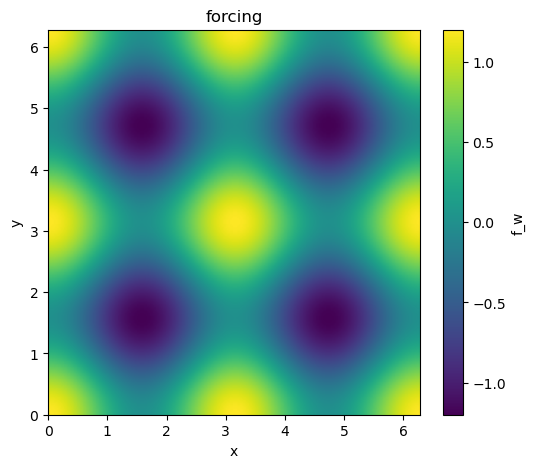

In [8]:
plt.figure(figsize=(6,5))
plt.imshow(f_w, origin='lower', extent=[0, L_x, 0, L_y], aspect='auto')
plt.colorbar(label='f_w')
plt.title('forcing')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [9]:
def single_droplet_phi(X, Y, xc, yc, R, epsilon):
    """
    Diffuse single-droplet initial condition matching the paper's convention:
        phi < 0 inside droplet
        phi > 0 in background

    Parameters
    ----------
    X, Y : 2D arrays
        Meshgrid arrays.
    xc, yc : float
        Droplet center.
    d0 : float
        Droplet diameter.
    xi : float
        Diffuse interface width parameter from the paper.
    """
    r = np.sqrt((X - xc)**2 + (Y - yc)**2)
    return np.tanh((R - r) / epsilon)

# Initialise phi - Smooth diffuse-interface droplet
# phi ≈ +1 inside droplet, phi ≈ -1 outside droplet
phi_xy = single_droplet_phi(X, Y, xc, yc, droplet_radius, epsilon)
phi_xy_hat = np.fft.fft2(phi_xy)

# Initial vorticity
omega_xy_0 = np.zeros_like(X)
omega_hat = np.fft.fft2(omega_xy_0)

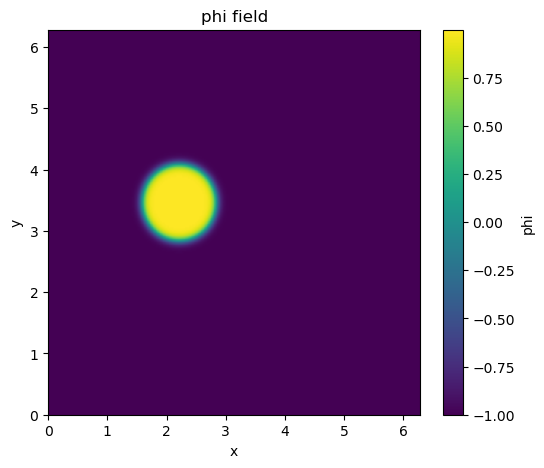

In [10]:
plt.figure(figsize=(6,5))
plt.imshow(phi_xy, origin='lower', extent=[0, L_x, 0, L_y], aspect='auto')
plt.colorbar(label='phi')
plt.title('phi field')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [11]:
# Integer Fourier mode indices for dealiasing
mx = np.fft.fftfreq(N_x) * N_x
my = np.fft.fftfreq(N_y) * N_y
MX, MY = np.meshgrid(mx, my, indexing='xy')

# 1/2-dealiasing mask for cubic nonlinearities
dealias_mask = ((np.abs(MX) < N_x//4) & (np.abs(MY) < N_y//4)).astype(float)

def dealias(hat_field):
    return hat_field * dealias_mask

In [12]:
# Assemble \mu using pseudo-spectral implementation

print("initial phi stats:", phi_xy.min(), phi_xy.max(), np.mean(phi_xy))
print("initial phi hat finite?", np.isfinite(phi_xy_hat).all())

def mu_spec(phi_hat, phi_xy):
    phi3_hat = dealias(np.fft.fft2(phi_xy**3))
    return (3/2)*sigma*epsilon*K2*phi_hat + (3/4)*(sigma/epsilon)*(phi3_hat - phi_hat)

initial phi stats: -1.0 0.9999998956355922 -0.9364584695917205
initial phi hat finite? True


In [13]:
# omega = vorticity field

def recover_velocity(omega_hat):
    psi_hat = np.zeros_like(omega_hat, dtype=complex)
    mask = (K2 != 0)
    psi_hat[mask] = omega_hat[mask] / K2[mask]

    u_x_hat = 1j * Ky * psi_hat
    u_y_hat = -1j * Kx * psi_hat

    u_x = np.fft.ifft2(u_x_hat).real
    u_y = np.fft.ifft2(u_y_hat).real

    return u_x,u_y

In [14]:
# Handling Non linear terms in CHNS equation

def advection_phi(phi_xy_hat, u_x, u_y):
    phi_x = np.fft.ifft2(1j * Kx * phi_xy_hat).real
    phi_y = np.fft.ifft2(1j * Ky * phi_xy_hat).real
    adv_xy = phi_x * u_x + phi_y * u_y
    return dealias(np.fft.fft2(adv_xy))

def advection_omega(omega_hat, u_x, u_y):
    omega_x = np.fft.ifft2(1j * Kx * omega_hat).real
    omega_y = np.fft.ifft2(1j * Ky * omega_hat).real
    adv_xy = omega_x * u_x + omega_y * u_y
    return dealias(np.fft.fft2(adv_xy))

# 2D vorticity equation
def coupling_term(phi_xy, mu_spec):
    mu_x = np.fft.ifft2(1j * Kx * mu_spec).real
    mu_y = np.fft.ifft2(1j * Ky * mu_spec).real

    term1_hat = dealias(np.fft.fft2(phi_xy * mu_y))
    term2_hat = dealias(np.fft.fft2(phi_xy * mu_x))

    return -(1j * Kx * term1_hat - 1j * Ky * term2_hat) # minus sign due to how coupling is defined in RP2

In [15]:
# Extraction of droplet geometry from phi

def polygon_area(x, y):
    """
    Shoelace formula for area of a closed polygon.
    """
    return 0.5 * np.abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))


def polygon_perimeter(x, y, closed=True):
    """
    Perimeter of a polygonal curve.
    """
    if closed:
        dx = np.diff(np.r_[x, x[0]])
        dy = np.diff(np.r_[y, y[0]])
    else:
        dx = np.diff(x)
        dy = np.diff(y)
    return np.sum(np.sqrt(dx**2 + dy**2))


def contour_pixels_to_physical(contour_rc, dx, dy):
    """
    skimage.find_contours returns coordinates as (row, col).
    Convert to physical x,y coordinates.
    """
    r = contour_rc[:, 0]
    c = contour_rc[:, 1]
    x = c * dx
    y = r * dy
    return x, y


def effective_diameter_from_area(A):
    """
    d_p = 2 * sqrt(A / pi)
    """
    return 2.0 * np.sqrt(A / np.pi)


def reference_circle_perimeter_from_area(A):
    """
    Perimeter of a circle with the same area A.
    S0 = pi * d_p = 2 * sqrt(pi A)
    """
    return 2.0 * np.sqrt(np.pi * A)


def deformation_parameter(S, A):
    """
    Gamma = S / S0 - 1
    """
    S0 = reference_circle_perimeter_from_area(A)
    return S / S0 - 1.0


def periodic_center_of_mass(mask, Lx, Ly):
    """
    Periodic-safe center of mass of a boolean mask.
    This avoids jumps when the droplet crosses the periodic boundary.
    """
    Ny, Nx = mask.shape

    # x coordinates
    x_idx = np.arange(Nx)
    theta_x = 2.0 * np.pi * x_idx / Nx
    wx = mask.sum(axis=0).astype(float)
    if wx.sum() == 0:
        return np.nan, np.nan

    Cx = np.sum(wx * np.cos(theta_x)) / np.sum(wx)
    Sx = np.sum(wx * np.sin(theta_x)) / np.sum(wx)
    ang_x = np.arctan2(Sx, Cx) % (2.0 * np.pi)
    x_cm = Lx * ang_x / (2.0 * np.pi)

    # y coordinates
    y_idx = np.arange(Ny)
    theta_y = 2.0 * np.pi * y_idx / Ny
    wy = mask.sum(axis=1).astype(float)
    Cy = np.sum(wy * np.cos(theta_y)) / np.sum(wy)
    Sy = np.sum(wy * np.sin(theta_y)) / np.sum(wy)
    ang_y = np.arctan2(Sy, Cy) % (2.0 * np.pi)
    y_cm = Ly * ang_y / (2.0 * np.pi)

    return x_cm, y_cm

def compute_com(phi_xy):
    """
    Droplet centre of mass using Appendix D of the paper.

    Parameters
    ----------
    phi_xy : 2D numpy array
        Phase-field variable phi(x,y).

    Returns
    -------
    X_CM, Y_CM : floats
        Centre-of-mass coordinates in angular units, i.e. in [0, 2*pi).
    """

    # 2D Fourier transform of phi
    phi_hat = np.fft.fft2(phi_xy)

    # NumPy convention:
    # phi_hat[0, 1] is the first Fourier mode in x
    # phi_hat[1, 0] is the first Fourier mode in y

    phi_hat_x = phi_hat[0, 1]
    phi_hat_y = phi_hat[1, 0]

    X_CM = np.arctan2(np.imag(phi_hat_x), np.real(phi_hat_x))
    Y_CM = np.arctan2(np.imag(phi_hat_y), np.real(phi_hat_y))

    # Convert from [-pi, pi] to [0, 2*pi)
    X_CM = X_CM % (2.0 * np.pi)
    Y_CM = Y_CM % (2.0 * np.pi)

    return X_CM, Y_CM


def extract_main_droplet_contour(phi_xy, level=0.0):
    """
    Extract all level-set contours and return the longest one.
    For a single-droplet setup, this is usually the main droplet boundary.
    """
    contours = measure.find_contours(phi_xy, level=level)

    if len(contours) == 0:
        return None

    # choose the longest contour in number of points
    contour = max(contours, key=lambda c: c.shape[0])
    return contour

def compute_free_energy(phi_xy, dx, dy, sigma, epsilon):
    """
    Free energy functional:

    F(phi) = ∫ [ 3/16 * sigma/epsilon * (phi^2 - 1)^2
               + 3/4 * sigma * epsilon * |grad phi|^2 ] dA
    """

    dphi_dy, dphi_dx = np.gradient(phi_xy, dy, dx)

    bulk = (3.0 / 16.0) * (sigma / epsilon) * (phi_xy**2 - 1.0)**2
    interface = (3.0 / 4.0) * sigma * epsilon * (dphi_dx**2 + dphi_dy**2)

    F = np.sum(bulk + interface) * dx * dy

    return F

def compute_structure_factor_phi(phi_xy, Lx, Ly):
    """
    Compute shell-averaged order-parameter spectrum S(k,t)
    as in the coarsening-length definition.

    Parameters
    ----------
    phi_xy : 2D array, shape (Ny, Nx)
        Phase-field variable.
    Lx, Ly : float
        Physical domain lengths.

    Returns
    -------
    k_shell : 1D array
        Integer shell wavenumbers.
    S_shell : 1D array
        Shell-summed spectrum S(k,t).
    """

    Ny, Nx = phi_xy.shape

    # Remove mean mode; important for asymmetric mixtures/droplets
    phi0 = phi_xy - np.mean(phi_xy)

    phi_hat = np.fft.fft2(phi0)

    # Physical wavenumbers
    kx = 2.0 * np.pi * np.fft.fftfreq(Nx, d=Lx / Nx)
    ky = 2.0 * np.pi * np.fft.fftfreq(Ny, d=Ly / Ny)

    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX**2 + KY**2)

    power = np.abs(phi_hat)**2

    # Shell index: k <= |k'| < k+1
    shell_index = np.floor(K).astype(int)

    k_max = shell_index.max()
    S_shell = np.zeros(k_max + 1)

    for k in range(k_max + 1):
        S_shell[k] = np.sum(power[shell_index == k])

    k_shell = np.arange(k_max + 1)

    # Remove k=0 shell
    return k_shell[1:], S_shell[1:]

def compute_coarsening_length(phi_xy, Lx, Ly):
    """
    Compute L(t) = 2*pi * sum_k S(k,t) / sum_k k S(k,t).
    """

    k, S = compute_structure_factor_phi(phi_xy, Lx, Ly)

    denominator = np.sum(k * S)

    if denominator <= 1e-14:
        return np.nan

    L_t = 2.0 * np.pi * np.sum(S) / denominator

    return L_t

def droplet_geometry_from_phi(phi_xy, dx, dy, Lx, Ly, level=0.0):
    """
    Compute droplet geometry from the phi=0 contour and phi<0 interior.

    Returns a dictionary with:
        area
        perimeter
        diameter
        gamma
        S0
        x_cm
        y_cm
        area_from_mask
        contour_xy
    """
    contour_rc = extract_main_droplet_contour(phi_xy, level=level)
    if contour_rc is None:
        return None

    # Contour-based geometry
    x_contour, y_contour = contour_pixels_to_physical(contour_rc, dx, dy)
    A_contour = polygon_area(x_contour, y_contour)
    S_contour = polygon_perimeter(x_contour, y_contour, closed=True)

    # Effective diameter and deformation
    d_p = effective_diameter_from_area(A_contour)
    S0 = reference_circle_perimeter_from_area(A_contour)
    Gamma = deformation_parameter(S_contour, A_contour)

    # COM for the droplet phase
    mask = (phi_xy > 0.0)
    A_mask = np.sum(mask) * dx * dy
    x_cm, y_cm = compute_com(phi_xy)

    # Compute free energy
    F_phi = compute_free_energy(phi_xy, del_x, del_y, sigma, epsilon)

    L_coarsening = compute_coarsening_length(phi_xy, L_x, L_y)

    return {
        "area": A_contour,
        "perimeter": S_contour,
        "diameter": d_p,
        "gamma": Gamma,
        "S0": S0,
        "x_cm": x_cm,
        "y_cm": y_cm,
        "area_from_mask": A_mask,
        "contour_x": x_contour,
        "contour_y": y_contour,
        "free_energy": F_phi,
        "L_coarsening": L_coarsening
    }


In [16]:
def initialize_droplet_tracking():
    return {
        "time": [],
        "area": [],
        "area_mask": [],
        "area_rel_error": [],
        "perimeter": [],
        "S0": [],
        "gamma": [],
        "diameter": [],
        "x_cm": [],
        "y_cm": [],
        "free_energy": [],
        "L_coarsening": []
    }

# Updating function during simulation
def update_droplet_tracking(track, t, phi_xy, dx, dy, Lx, Ly, A0=None):
    geom = droplet_geometry_from_phi(phi_xy, dx, dy, Lx, Ly, level=0.0)

    if geom is None:
        return track, A0

    if A0 is None:
        A0 = geom["area"]

    rel_err = (geom["area"] - A0) / A0

    track["time"].append(t)
    track["area"].append(geom["area"])
    track["area_mask"].append(geom["area_from_mask"])
    track["area_rel_error"].append(rel_err)
    track["perimeter"].append(geom["perimeter"])
    track["S0"].append(geom["S0"])
    track["gamma"].append(geom["gamma"])
    track["diameter"].append(geom["diameter"])
    track["x_cm"].append(geom["x_cm"])
    track["y_cm"].append(geom["y_cm"])
    track["free_energy"].append(geom['free_energy'])
    track['L_coarsening'].append(geom['L_coarsening'])

    return track, A0

In [17]:
def compute_droplet_center_of_mass(phi_xy):
    """
    Compute droplet centre of mass for a diffuse-interface droplet.

    Assumes:
        phi ≈ +1 inside droplet
        phi ≈ -1 outside droplet

    Uses:
        w = (phi + 1)/2
    """

    w = (phi_xy + 1.0) / 2.0

    total_weight = np.sum(w)

    if total_weight <= 1e-14:
        return np.nan, np.nan

    x_cm = np.sum(X * w) / total_weight
    y_cm = np.sum(Y * w) / total_weight

    return x_cm, y_cm


def compute_phase_mass(phi_xy):
    return np.sum(phi_xy) * del_x * del_y


def compute_phase_volume(phi_xy):
    return np.sum((phi_xy + 1.0) / 2.0) * del_x * del_y

def compute_kinetic_energy(u_x, u_y):
    return 0.5 * np.sum(u_x**2 + u_y**2) * del_x * del_y


def compute_enstrophy(omega_xy):
    return 0.5 * np.sum(omega_xy**2) * del_x * del_y


def compute_divergence_errors(u_x, u_y):
    u_x_hat = np.fft.fft2(u_x)
    u_y_hat = np.fft.fft2(u_y)

    div_hat = 1j * Kx * u_x_hat + 1j * Ky * u_y_hat
    div_xy = np.fft.ifft2(div_hat).real

    return np.max(np.abs(div_xy)), np.sqrt(np.mean(div_xy**2))


def compute_forced_mode_fraction(omega_hat, k_f, tolerance=1e-14):
    spectral_energy = np.abs(omega_hat)**2
    total_energy = np.sum(spectral_energy)

    if total_energy < tolerance:
        return np.nan

    forced_mask = (
        ((np.isclose(np.abs(Kx), k_f)) & (np.isclose(Ky, 0.0)))
        |
        ((np.isclose(Kx, 0.0)) & (np.isclose(np.abs(Ky), k_f)))
    )

    forced_energy = np.sum(spectral_energy[forced_mask])
    return forced_energy / total_energy


def compute_interface_length(phi_xy):
    """
    Approximate length of the phi = 0 interface.
    """
    contours = measure.find_contours(phi_xy, level=0.0)

    total_length = 0.0

    for contour in contours:
        y_idx = contour[:, 0]
        x_idx = contour[:, 1]

        x_phys = x_idx * del_x
        y_phys = y_idx * del_y

        dx_c = np.diff(x_phys)
        dy_c = np.diff(y_phys)

        total_length += np.sum(np.sqrt(dx_c**2 + dy_c**2))

    return total_length



In [18]:
# Time stepping 

def G(omega_hat,phi_xy,mu_s,u_x,u_y):
    if coupling:
        return -(advection_omega(omega_hat,u_x,u_y)) + coupling_term(phi_xy,mu_s) + f_w_hat
    else:
        return -(advection_omega(omega_hat,u_x,u_y)) + f_w_hat

def H(phi_xy_hat,phi_xy,u_x,u_y):
    if evolve_phi:
        return -(advection_phi(phi_xy_hat,u_x,u_y)) - (3/4)*(sigma/epsilon)*M*K2*dealias(np.fft.fft2(phi_xy**3))
    else:
        return - (3/4)*(sigma/epsilon)*M*K2*dealias(np.fft.fft2(phi_xy**3))


In [19]:
# Time stepping
q_01 = omega_hat
q_02 = phi_xy_hat

q_01_n = q_01
q_02_n = q_02

omega_history = [omega_xy_0.copy()]
phi_history = [np.fft.ifft2(q_02_n).real.copy()]
time_history = [0.0]


phi_initial = np.fft.ifft2(q_02_n).real
x_cm0, y_cm0 = compute_com(phi_initial)

center_x_history = [x_cm0]
center_y_history = [y_cm0]

phase_mass_history = []
phase_mass_error_history = []

phase_volume_history = []
phase_volume_error_history = []

kinetic_energy_history = []
enstrophy_history = []
max_divergence_history = []
l2_divergence_history = []
forced_mode_fraction_history = []

min_phi_history = []
max_phi_history = []
interface_length_history = []

track = initialize_droplet_tracking()
A0 = None

# track initial condition
phi0 = np.fft.ifft2(phi_xy_hat).real
track, A0 = update_droplet_tracking(track, 0.0, phi0, del_x, del_y, L_x, L_y, A0=A0)

phi_initial = np.fft.ifft2(q_02_n).real
phase_mass_initial = compute_phase_mass(phi_initial)
phase_volume_initial = compute_phase_volume(phi_initial)

# Masked handling for lambda = 0
E_01 = np.exp(lamda_01*delta_t)
E_02 = np.exp(lamda_02*delta_t)

mask_01 = (np.abs(lamda_01) > 1e-14)
mask_02 = (np.abs(lamda_02) > 1e-14)

# Masked handling for lambda = 0

phi1 = np.empty_like(lamda_01, dtype=complex)
phi2 = np.empty_like(lamda_02, dtype=complex)

phi1[mask_01] = (E_01[mask_01] - 1)/lamda_01[mask_01]
phi2[mask_02] = (E_02[mask_02] - 1)/lamda_02[mask_02]

phi1[~mask_01] = delta_t
phi2[~mask_02] = delta_t

phi_1 = np.empty_like(lamda_01, dtype=complex)
phi_2 = np.empty_like(lamda_02, dtype=complex)

phi_1[mask_01] = (E_01[mask_01] - 1 - lamda_01[mask_01] * delta_t)/(lamda_01[mask_01]**2 * delta_t)
phi_2[mask_02] = (E_02[mask_02] - 1 - lamda_02[mask_02] * delta_t)/(lamda_02[mask_02]**2 * delta_t)

phi_1[~mask_01] = 0.5 * delta_t
phi_2[~mask_02] = 0.5 * delta_t

for n in range(0,N_t):
    t = n * delta_t
    # Block A: Recomputation

    # A.1) Extracting velocity from omega_hat_n
    u_x_n,u_y_n = recover_velocity(q_01_n)

    # A.2) Re-computing terms
    phi_intermediate = np.fft.ifft2(q_02_n).real
    mu_spec_n = mu_spec(q_02_n,phi_intermediate)

    # A.3) Non-linear terms
    G_n = G(q_01_n,phi_intermediate,mu_spec_n,u_x_n,u_y_n)
    H_n = H(q_02_n,phi_intermediate,u_x_n,u_y_n)

    # Block B: Predictor

    a_01_n = q_01_n * np.exp(lamda_01 * delta_t) + (G_n * phi1)
    a_02_n = q_02_n * np.exp(lamda_02 * delta_t) + (H_n * phi2)

    # Block C: Intermediate state reconstruction
    # C.1) Recover velocity from a_01_n
    u_x_a, u_y_a = recover_velocity(a_01_n)

    # C.2) Recover phi from a_02_n
    phi_a = np.fft.ifft2(a_02_n).real
    mu_spec_a = mu_spec(a_02_n,phi_a)

    # Block D: Final assembly

    G_a = G(a_01_n,phi_a,mu_spec_a,u_x_a,u_y_a)
    H_a = H(a_02_n,phi_a,u_x_a,u_y_a)

    q_01_next = a_01_n + (G_a - G_n) * phi_1
    q_02_next = a_02_n + (H_a - H_n) * phi_2

    if not np.isfinite(q_01_next).all() or not np.isfinite(q_02_next).all():
        print("NaN/Inf detected at step", n)
        break

    q_01_next = dealias(q_01_next)
    q_02_next = dealias(q_02_next)

    if n % save_every == 0:
        track, A0 = update_droplet_tracking(
            track, t, np.fft.ifft2(q_02_next).real, del_x, del_y, L_x, L_y, A0=A0
        )
        omega_history.append(np.fft.ifft2(q_01_next).real.copy())
        phi_history.append(np.fft.ifft2(q_02_next).real.copy())
        time_history.append(n * delta_t)
        forced_mode_fraction_history.append(
            compute_forced_mode_fraction(q_01_next, k_f)
        )

        omega_save = np.fft.ifft2(q_01_next).real
        u_x_save, u_y_save = recover_velocity(q_01_next)

        kinetic_energy_history.append(compute_kinetic_energy(u_x_save, u_y_save))
        enstrophy_history.append(compute_enstrophy(omega_save))

        max_div, l2_div = compute_divergence_errors(u_x_save, u_y_save)
        max_divergence_history.append(max_div)
        l2_divergence_history.append(l2_div)

        phi_save = np.fft.ifft2(q_02_next).real
        x_cm, y_cm = compute_com(phi_save)
        center_x_history.append(x_cm)
        center_y_history.append(y_cm)

        min_phi_history.append(np.min(phi_save))
        max_phi_history.append(np.max(phi_save))

        interface_length = compute_interface_length(phi_save)
        interface_length_history.append(interface_length)

        phase_mass = compute_phase_mass(phi_save)
        phase_volume = compute_phase_volume(phi_save)

        phase_mass_history.append(phase_mass)
        phase_mass_error_history.append(abs(phase_mass - phase_mass_initial))

        phase_volume_history.append(phase_volume)
        phase_volume_error_history.append(abs(phase_volume - phase_volume_initial))

    if n % save_every == 0:
            print(
            f"step {n}/{N_t}, "
            f"KE={kinetic_energy_history[-1]:.4e}, "
            f"Z={enstrophy_history[-1]:.4e}, "
            f"forced_frac={forced_mode_fraction_history[-1]:.4f}, "
            f"mass_err={phase_mass_error_history[-1]:.2e}, "
        )
    
    # Final omega hat
    q_01_n = q_01_next

    # Final phi_hat
    q_02_n = q_02_next

for key in track:
    track[key] = np.array(track[key])

center_x_history = np.array(center_x_history)
center_y_history = np.array(center_y_history)
min_phi_history = np.array(min_phi_history)
max_phi_history = np.array(max_phi_history)
interface_length_history = np.array(interface_length_history)


step 0/50000, KE=2.8426e-07, Z=1.2767e-06, forced_frac=0.8905, mass_err=7.11e-15, 
step 100/50000, KE=2.8802e-03, Z=1.1559e-02, forced_frac=0.9966, mass_err=0.00e+00, 
step 200/50000, KE=1.1326e-02, Z=4.5335e-02, forced_frac=0.9993, mass_err=0.00e+00, 
step 300/50000, KE=2.5207e-02, Z=1.0104e-01, forced_frac=0.9978, mass_err=0.00e+00, 
step 400/50000, KE=4.4384e-02, Z=1.7836e-01, forced_frac=0.9952, mass_err=7.11e-15, 
step 500/50000, KE=6.8714e-02, Z=2.7711e-01, forced_frac=0.9914, mass_err=0.00e+00, 
step 600/50000, KE=9.8052e-02, Z=3.9718e-01, forced_frac=0.9867, mass_err=7.11e-15, 
step 700/50000, KE=1.3225e-01, Z=5.3852e-01, forced_frac=0.9811, mass_err=7.11e-15, 
step 800/50000, KE=1.7118e-01, Z=7.0105e-01, forced_frac=0.9749, mass_err=0.00e+00, 
step 900/50000, KE=2.1471e-01, Z=8.8474e-01, forced_frac=0.9681, mass_err=7.11e-15, 
step 1000/50000, KE=2.6269e-01, Z=1.0895e+00, forced_frac=0.9609, mass_err=0.00e+00, 
step 1100/50000, KE=3.1502e-01, Z=1.3153e+00, forced_frac=0.9535, 

In [20]:
print("Run completed with T =", T, "N_t =", N_t, "delta_t =", delta_t)
print("omega final min/max:", omega_history[-1].min(), omega_history[-1].max())
print("len(omega_history) =", len(omega_history))

Run completed with T = 20.0 N_t = 50000 delta_t = 0.0004
omega final min/max: -5.042421733167088 5.154084492859692
len(omega_history) = 501


In [21]:
print("final phi stats:", phi_history[-1].min(), phi_history[-1].max(), np.mean(phi_history[-1]))
print("final omega stats:", omega_history[-1].min(), omega_history[-1].max())
print("all phi finite?", np.isfinite(np.array(phi_history)).all())
print("all omega finite?", np.isfinite(np.array(omega_history)).all())

final phi stats: -1.016398771005841 1.0614508809716041 -0.9364584695917205
final omega stats: -5.042421733167088 5.154084492859692
all phi finite? True
all omega finite? True


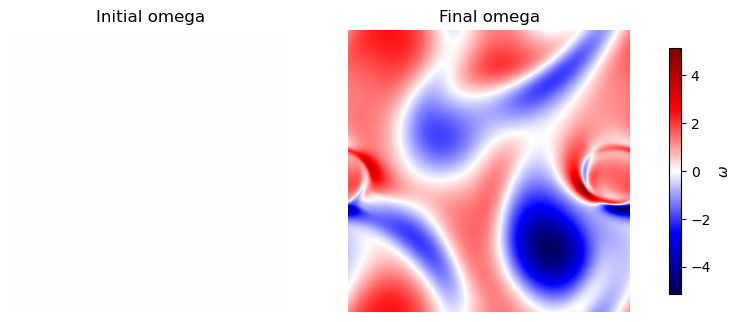

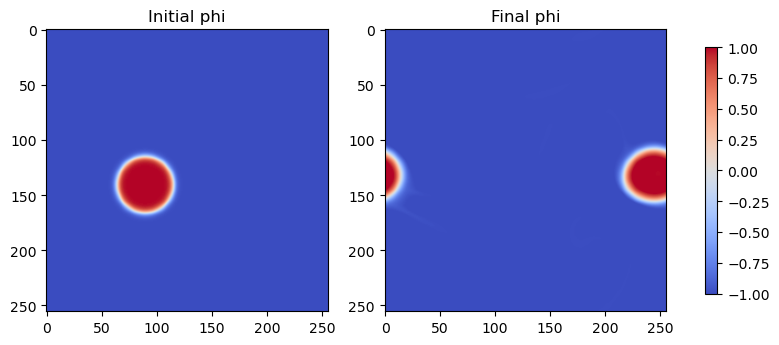

In [22]:
# Initial and final omega snapshots

omega_abs_max = max(
    np.max(np.abs(omega_history[0])),
    np.max(np.abs(omega_history[-1]))
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(
    omega_history[0],
    vmin=-omega_abs_max,
    vmax=omega_abs_max,
    cmap="seismic"
)
axes[0].set_title("Initial omega")
axes[0].set_aspect("equal")
axes[0].axis("off")

im1 = axes[1].imshow(
    omega_history[-1],
    vmin=-omega_abs_max,
    vmax=omega_abs_max,
    cmap="seismic"
)
axes[1].set_title("Final omega")
axes[1].set_aspect("equal")
axes[1].axis("off")

fig.colorbar(im1, ax=axes, shrink=0.8, label=r"$\omega$")
plt.show()

# Initial and final phi snapshots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(phi_history[0], vmin=-1, vmax=1, cmap="coolwarm")
axes[0].set_title("Initial phi")
axes[0].set_aspect("equal")

im1 = axes[1].imshow(phi_history[-1], vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set_title("Final phi")
axes[1].set_aspect("equal")

fig.colorbar(im1, ax=axes, shrink=0.8)
plt.show()

In [23]:
def plot_field_snapshots(
    field_history,
    time_history=None,
    indices=None,
    title=None,
    cmap="coolwarm",
    vmin=None,
    vmax=None,
    extent=None,
    contour_history=None,
    contour_level=0.0,
    contour_color="black",
    figsize=(16, 4),
):
    """
    Plot snapshots of a scalar field in one row.

    Parameters
    ----------
    field_history : array, shape (nt, Nx, Ny)
        Saved scalar field over time.
    time_history : array, optional
        Saved time values.
    indices : list[int], optional
        Indices to plot. If None, plots [0, nt/3, 2nt/3, nt-1].
    title : str, optional
        Figure title.
    cmap : str
        Matplotlib colormap.
    vmin, vmax : float, optional
        Fixed color limits.
    extent : tuple, optional
        Extent for imshow, e.g. (0, Lx, 0, Ly).
    contour_history : array, optional
        If provided, overlays contour_history[index] at contour_level.
        Useful for overlaying phi=0 contour on vorticity.
    contour_level : float
        Contour level.
    contour_color : str
        Contour color.
    figsize : tuple
        Figure size.
    """

    nt = len(field_history)

    if indices is None:
        indices = [0, nt // 3, 2 * nt // 3, nt - 1]

    # Remove duplicates if nt is small
    indices = list(dict.fromkeys(indices))

    fig, axes = plt.subplots(1, len(indices), figsize=figsize, constrained_layout=True)

    if len(indices) == 1:
        axes = [axes]

    # Use global symmetric scale if vmin/vmax not given and field has positive/negative values
    if vmin is None or vmax is None:
        max_abs = np.nanmax(np.abs(field_history[indices]))
        vmin = -max_abs
        vmax = max_abs

    im = None

    for ax, idx in zip(axes, indices):
        field = field_history[idx]

        im = ax.imshow(
            field.T,
            origin="lower",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            extent=extent,
            aspect="equal",
        )

        if contour_history is not None:
            ax.contour(
                contour_history[idx].T,
                levels=[contour_level],
                colors=contour_color,
                linewidths=1.5,
                extent=extent,
            )

        if time_history is not None:
            ax.set_title(f"t = {time_history[idx]:.3g}")
        else:
            ax.set_title(f"snapshot {idx}")

        ax.set_xlabel("x")
        ax.set_ylabel("y")

    if title is not None:
        fig.suptitle(title, fontsize=14)

    fig.colorbar(im, ax=axes, shrink=0.85)
    plt.show()

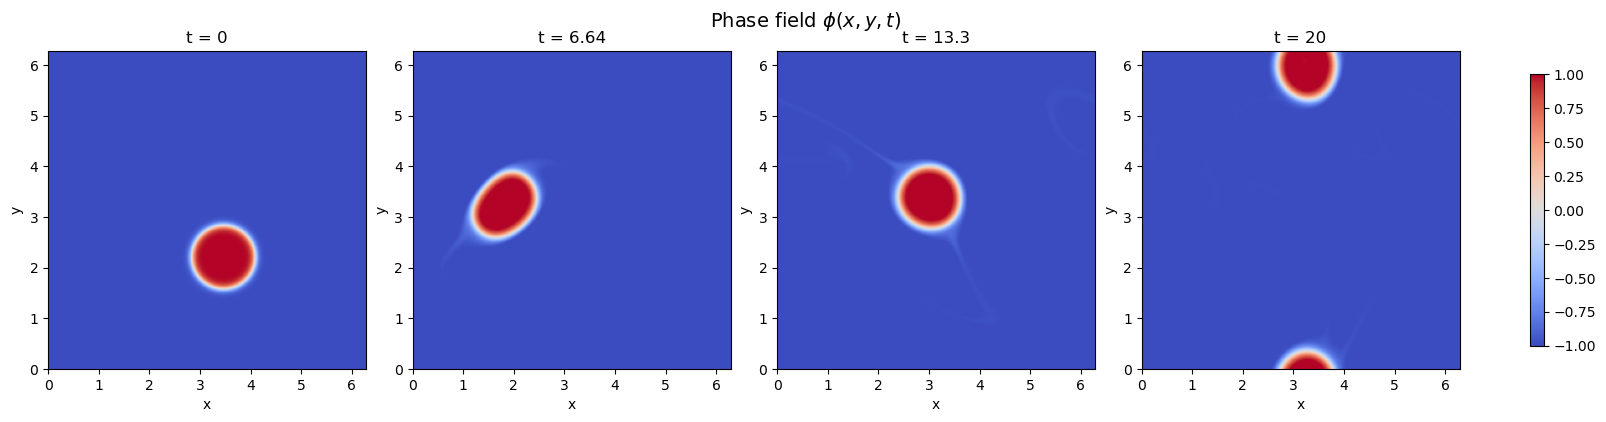

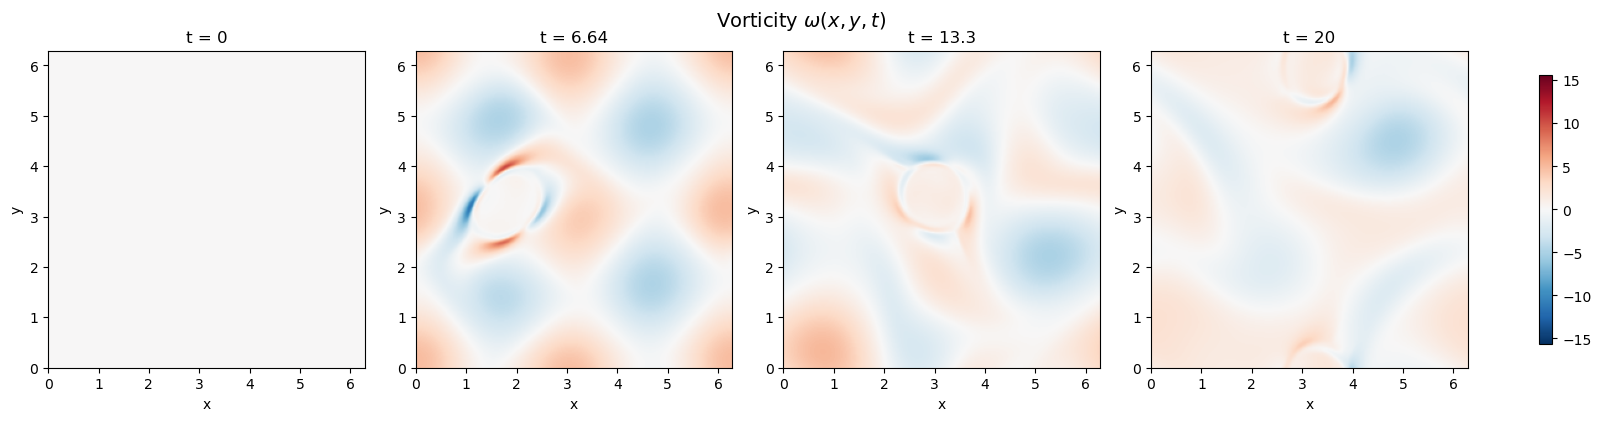

In [24]:
plot_field_snapshots(
    phi_history,
    time_history=time_history,
    title=r"Phase field $\phi(x,y,t)$",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    extent=(0, L_x, 0, L_y),
)

omega_abs = np.nanmax(np.abs(omega_history))

plot_field_snapshots(
    omega_history,
    time_history=time_history,
    title=r"Vorticity $\omega(x,y,t)$",
    cmap="RdBu_r",
    vmin=-omega_abs,
    vmax=omega_abs,
    extent=(0, L_x, 0, L_y),
)

In [25]:
def animate_omega_with_contour_imshow(omega_history, phi_history, time_history, L_x, L_y,
                                      interval=100):
    omega_history = np.asarray(omega_history)
    phi_history = np.asarray(phi_history)
    time_history = np.asarray(time_history)

    fig, ax = plt.subplots(figsize=(6, 6))

    vmin = np.min(omega_history)
    vmax = np.max(omega_history)

    im = ax.imshow(
        omega_history[0],
        origin="lower",
        extent=[0, L_x, 0, L_y],
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        aspect="equal"
    )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("omega")

    contour = ax.contour(
        np.linspace(0, L_x, phi_history.shape[2]),
        np.linspace(0, L_y, phi_history.shape[1]),
        phi_history[0],
        levels=[0.0],
        colors="k",
        linewidths=2
    )

    title = ax.set_title(f"omega with droplet contour, t = {time_history[0]:.4f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    def update(frame):
        nonlocal contour

        im.set_data(omega_history[frame])

        if contour is not None:
            contour.remove()

        contour = ax.contour(
            np.linspace(0, L_x, phi_history.shape[2]),
            np.linspace(0, L_y, phi_history.shape[1]),
            phi_history[frame],
            levels=[0.0],
            colors="k",
            linewidths=2
        )

        title.set_text(f"omega with droplet contour, t = {time_history[frame]:.4f}")
        return [im, title]

    anim = animation.FuncAnimation(fig, update, frames=len(time_history), interval=interval, blit=False)
    plt.close(fig)
    return anim

anim = animate_omega_with_contour_imshow(
    omega_history=omega_history,
    phi_history=phi_history,
    time_history=time_history,
    L_x=L_x,
    L_y=L_y,
    interval=120
)

output_path = animations_dir / fully_coupled_omega_with_contour
anim.save(output_path, writer="pillow", fps=8)
print(f"Saved omega animation to {output_path}")

Saved omega animation to Results/Experiment_DD_fully_coupled/fully_coupled_omega_with_contour_final.gif


Saved phi animation to Results/Experiment_DD_fully_coupled/fully_coupled_phi_final.gif


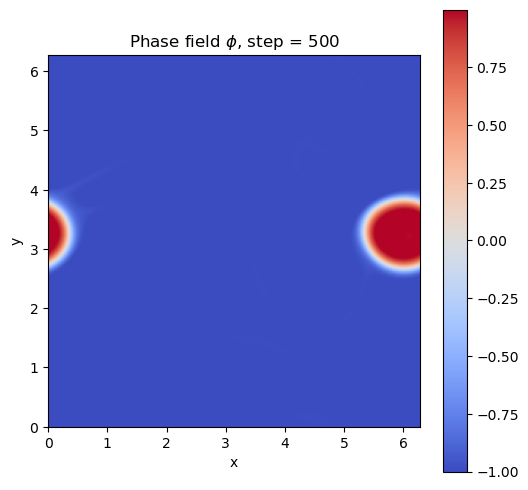

In [26]:
fig, ax = plt.subplots(figsize=(6,6))

im = ax.imshow(
    phi_history[0],
    origin='lower',
    extent=[0, L_x, 0, L_y],
    cmap='coolwarm',
    animated=True
)
ax.set_title("Phase field $\\phi$")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax)

def update(frame):
    im.set_array(phi_history[frame])
    ax.set_title(f"Phase field $\\phi$, step = {frame}")
    return [im]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(phi_history),
    interval=50,
    blit=True
)

output_path = animations_dir / fully_coupled_phi
ani.save(output_path, writer="pillow", fps=15)
print(f"Saved phi animation to {output_path}")

In [27]:
print(phi_history[0].min(), phi_history[0].max(), np.mean(phi_history[0]))

-1.0000000000000009 0.9999998956355924 -0.9364584695917205


### Validation:

1. Flow transition/change:
   kinetic energy, enstrophy, forced-mode fraction, vorticity snapshots

2. Droplet response:
   centre of mass, deformation, interface length, circularity, phase mass

3. Coupling strength:
   how large the interfacial feedback is compared with the external forcing

In [28]:
# Figure 1: Full CHNS validation summary

def plot_figure_1_validation_summary(
    time_history,
    max_divergence_history,
    l2_divergence_history,
    phase_mass_error_history,
    phase_volume_error_history,
    min_phi_history,
    max_phi_history
):
    """
    Figure 1:
    Numerical validation of the fully coupled CHNS simulation.

    Panels:
        (a) divergence error
        (b) phase mass conservation error summary
        (c) phase-volume conservation error summary
        (d) min(phi), max(phi)
    """

    time_history = np.asarray(time_history)

    max_divergence_history = np.asarray(max_divergence_history)
    l2_divergence_history = np.asarray(l2_divergence_history)

    phase_mass_error_history = np.asarray(phase_mass_error_history)
    phase_volume_error_history = np.asarray(phase_volume_error_history)

    min_phi_history = np.asarray(min_phi_history)
    max_phi_history = np.asarray(max_phi_history)

    n = min(
        len(time_history),
        len(max_divergence_history),
        len(l2_divergence_history),
        len(phase_mass_error_history),
        len(phase_volume_error_history),
        len(min_phi_history),
        len(max_phi_history)
    )

    t = time_history[:n]

    max_divergence_history = max_divergence_history[:n]
    l2_divergence_history = l2_divergence_history[:n]

    phase_mass_error_history = phase_mass_error_history[:n]
    phase_volume_error_history = phase_volume_error_history[:n]

    min_phi_history = min_phi_history[:n]
    max_phi_history = max_phi_history[:n]

    # Avoid log(0) issues in bar plots
    eps_floor = 1e-18

    phase_mass_final_error = max(phase_mass_error_history[-1], eps_floor)
    phase_mass_max_error = max(np.max(phase_mass_error_history), eps_floor)

    phase_volume_final_error = max(phase_volume_error_history[-1], eps_floor)
    phase_volume_max_error = max(np.max(phase_volume_error_history), eps_floor)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # --------------------------------------------------------
    # (a) Divergence error
    # --------------------------------------------------------

    ax = axes[0, 0]

    ax.semilogy(t, np.maximum(max_divergence_history, eps_floor), label="Max divergence")
    ax.semilogy(t, np.maximum(l2_divergence_history, eps_floor), label="L2 divergence")

    ax.set_xlabel("Time")
    ax.set_ylabel("Divergence error")
    ax.set_title("(a) Incompressibility check")
    ax.grid(True)
    ax.legend()

    # --------------------------------------------------------
    # (b) Phase mass conservation summary
    # --------------------------------------------------------

    ax = axes[0, 1]

    labels = ["Final error", "Max error"]
    values = [phase_mass_final_error, phase_mass_max_error]

    ax.bar(labels, values)
    ax.set_yscale("log")
    ax.set_ylabel("Absolute error")
    ax.set_title("(b) Phase mass conservation")
    ax.grid(True, axis="y")

    for i, value in enumerate(values):
        ax.text(
            i,
            value,
            f"{value:.1e}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    # --------------------------------------------------------
    # (c) Phase-volume conservation summary
    # --------------------------------------------------------

    ax = axes[1, 0]

    labels = ["Final error", "Max error"]
    values = [phase_volume_final_error, phase_volume_max_error]

    ax.bar(labels, values)
    ax.set_yscale("log")
    ax.set_ylabel("Absolute error")
    ax.set_title("(c) Mass-based phase-volume conservation")
    ax.grid(True, axis="y")

    for i, value in enumerate(values):
        ax.text(
            i,
            value,
            f"{value:.1e}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    # --------------------------------------------------------
    # (d) Phi range
    # --------------------------------------------------------

    ax = axes[1, 1]

    ax.plot(t, min_phi_history, label=r"$\min(\phi)$")
    ax.plot(t, max_phi_history, label=r"$\max(\phi)$")

    ax.axhline(-1.0, linestyle="--", linewidth=1, label=r"$\phi=-1$")
    ax.axhline(1.0, linestyle="--", linewidth=1, label=r"$\phi=1$")

    ax.set_xlabel("Time")
    ax.set_ylabel(r"$\phi$ range")
    ax.set_title("(d) Phase-field boundedness")
    ax.grid(True)
    ax.legend()

    fig.suptitle("Figure 1: Full CHNS validation summary", fontsize=14)
    plt.tight_layout()
    plt.show()
    plt.savefig(animations_dir / validation_summary_fig)

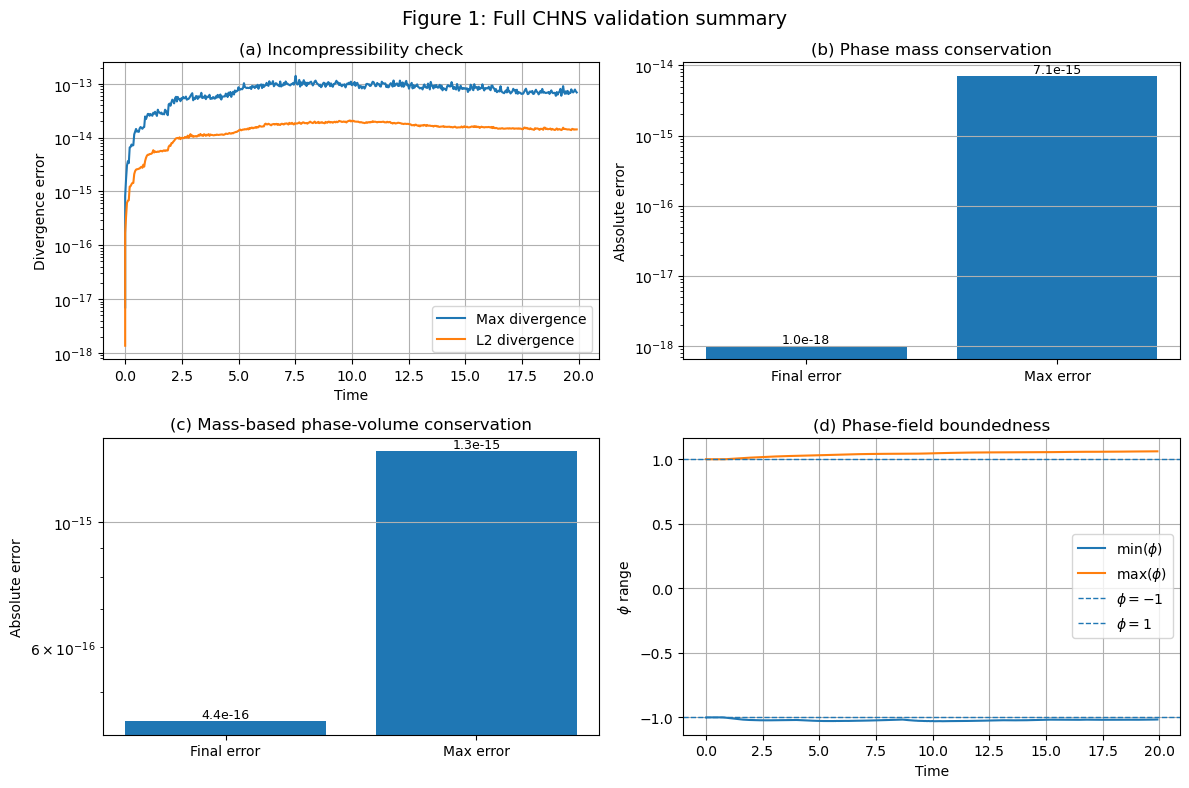

========== CONSERVATION SUMMARY ==========
Final phase mass error    = 0.000e+00
Max phase mass error      = 7.105e-15
Final phase-volume error  = 4.441e-16
Max phase-volume error    = 1.332e-15


<Figure size 640x480 with 0 Axes>

In [29]:
plot_figure_1_validation_summary(
    time_history=time_history,
    max_divergence_history=max_divergence_history,
    l2_divergence_history=l2_divergence_history,
    phase_mass_error_history=phase_mass_error_history,
    phase_volume_error_history=phase_volume_error_history,
    min_phi_history=min_phi_history,
    max_phi_history=max_phi_history
)
print("========== CONSERVATION SUMMARY ==========")
print(f"Final phase mass error    = {phase_mass_error_history[-1]:.3e}")
print(f"Max phase mass error      = {np.max(phase_mass_error_history):.3e}")
print(f"Final phase-volume error  = {phase_volume_error_history[-1]:.3e}")
print(f"Max phase-volume error    = {np.max(phase_volume_error_history):.3e}")

In [30]:

# Figure 2: Flow transition response


def plot_figure_2_flow_response(
    time_history,
    kinetic_energy_history,
    enstrophy_history,
    forced_mode_fraction_history
):
    """
    Figure 2:
    Flow transition indicators for the fully coupled CHNS simulation.

    Panels:
        (a) kinetic energy
        (b) enstrophy
        (c) forced-mode energy fraction
    """

    time_history = np.asarray(time_history)

    kinetic_energy_history = np.asarray(kinetic_energy_history)
    enstrophy_history = np.asarray(enstrophy_history)
    forced_mode_fraction_history = np.asarray(forced_mode_fraction_history)

    n = min(
        len(time_history),
        len(kinetic_energy_history),
        len(enstrophy_history),
        len(forced_mode_fraction_history)
    )

    t = time_history[:n]

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

    # --------------------------------------------------------
    # (a) Kinetic energy
    # --------------------------------------------------------

    ax = axes[0]

    ax.plot(t, kinetic_energy_history[:n])

    ax.set_xlabel("Time")
    ax.set_ylabel(r"Kinetic energy $E_k$")
    ax.set_title("(a) Kinetic energy")
    ax.grid(True)

    # --------------------------------------------------------
    # (b) Enstrophy
    # --------------------------------------------------------

    ax = axes[1]

    ax.plot(t, enstrophy_history[:n])

    ax.set_xlabel("Time")
    ax.set_ylabel(r"Enstrophy $Z$")
    ax.set_title("(b) Enstrophy")
    ax.grid(True)

    # --------------------------------------------------------
    # (c) Forced-mode fraction
    # --------------------------------------------------------

    ax = axes[2]

    ax.plot(t, forced_mode_fraction_history[:n])
    ax.set_ylim(-0.05, 1.05)

    ax.set_xlabel("Time")
    ax.set_ylabel("Forced-mode energy fraction")
    ax.set_title("(c) Forced-mode dominance")
    ax.grid(True)

    fig.suptitle("Figure 2: Flow transition response", fontsize=14)
    plt.tight_layout()
    plt.show()
    plt.savefig(animations_dir / flow_transition_fig)

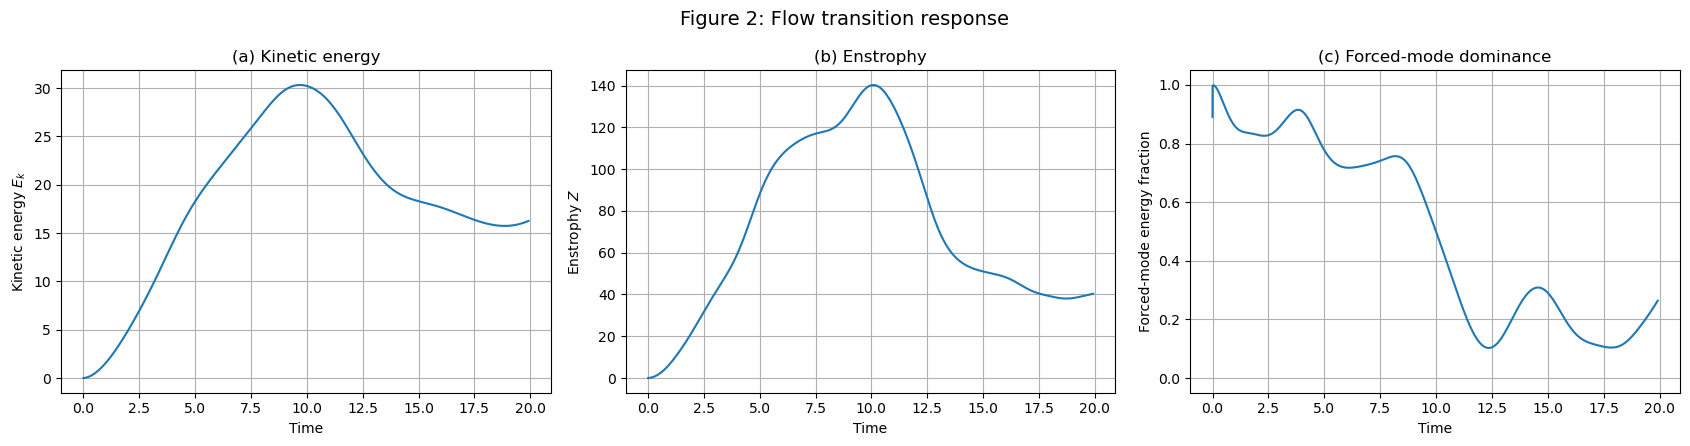

<Figure size 640x480 with 0 Axes>

In [31]:
plot_figure_2_flow_response(
    time_history=time_history,
    kinetic_energy_history=kinetic_energy_history,
    enstrophy_history=enstrophy_history,
    forced_mode_fraction_history=forced_mode_fraction_history
)

In [32]:

# Figure 3: Droplet motion and deformation


def plot_figure_3_droplet_motion(
    time_history,
    center_x_history,
    center_y_history,
    L_x,
    L_y,
    interface_length_history=None,
    track=None
):
    """
    Figure 3:
    Droplet motion and deformation.

    Panels:
        (a) centre-of-mass trajectory
        (b) x_cm(t), y_cm(t)
        (c) interface length / perimeter

    Either provide:
        interface_length_history

    or provide:
        track with track["perimeter"].
    """

    time_history = np.asarray(time_history)
    center_x_history = np.asarray(center_x_history)
    center_y_history = np.asarray(center_y_history)

    if interface_length_history is None:
        if track is not None and "perimeter" in track:
            interface_length_history = np.asarray(track["perimeter"])
        else:
            raise ValueError(
                "Provide either interface_length_history or track['perimeter']."
            )
    else:
        interface_length_history = np.asarray(interface_length_history)

    n = min(
        len(time_history),
        len(center_x_history),
        len(center_y_history),
        len(interface_length_history)
    )

    t = time_history[:n]
    x_cm = center_x_history[:n]
    y_cm = center_y_history[:n]
    interface_length = interface_length_history[:n]

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

    # --------------------------------------------------------
    # (a) Centre-of-mass trajectory
    # --------------------------------------------------------

    ax = axes[0]

    ax.plot(x_cm, y_cm, marker="o", markersize=2, linewidth=1)
    ax.scatter(x_cm[0], y_cm[0], s=60, label="start")
    ax.scatter(x_cm[-1], y_cm[-1], s=60, label="end")

    ax.set_xlabel(r"$x_c$")
    ax.set_ylabel(r"$y_c$")
    ax.set_title("(a) Centre-of-mass trajectory")
    ax.set_xlim(0, L_x)
    ax.set_ylim(0, L_y)
    ax.set_aspect("equal")
    ax.grid(True)
    ax.legend()

    # --------------------------------------------------------
    # (b) Centre-of-mass coordinates vs time
    # --------------------------------------------------------

    ax = axes[1]

    ax.plot(t, x_cm, label=r"$x_c(t)$")
    ax.plot(t, y_cm, label=r"$y_c(t)$")

    ax.set_xlabel("Time")
    ax.set_ylabel("Centre of mass")
    ax.set_title("(b) Centre-of-mass coordinates")
    ax.grid(True)
    ax.legend()

    # --------------------------------------------------------
    # (c) Interface length / perimeter
    # --------------------------------------------------------

    ax = axes[2]

    ax.plot(t, interface_length)

    ax.set_xlabel("Time")
    ax.set_ylabel("Interface length / perimeter")
    ax.set_title("(c) Interface stretching")
    ax.grid(True)

    fig.suptitle("Figure 3: Droplet motion and deformation", fontsize=14)
    plt.tight_layout()
    plt.show()
    plt.savefig(animations_dir / droplet_motion_fig)

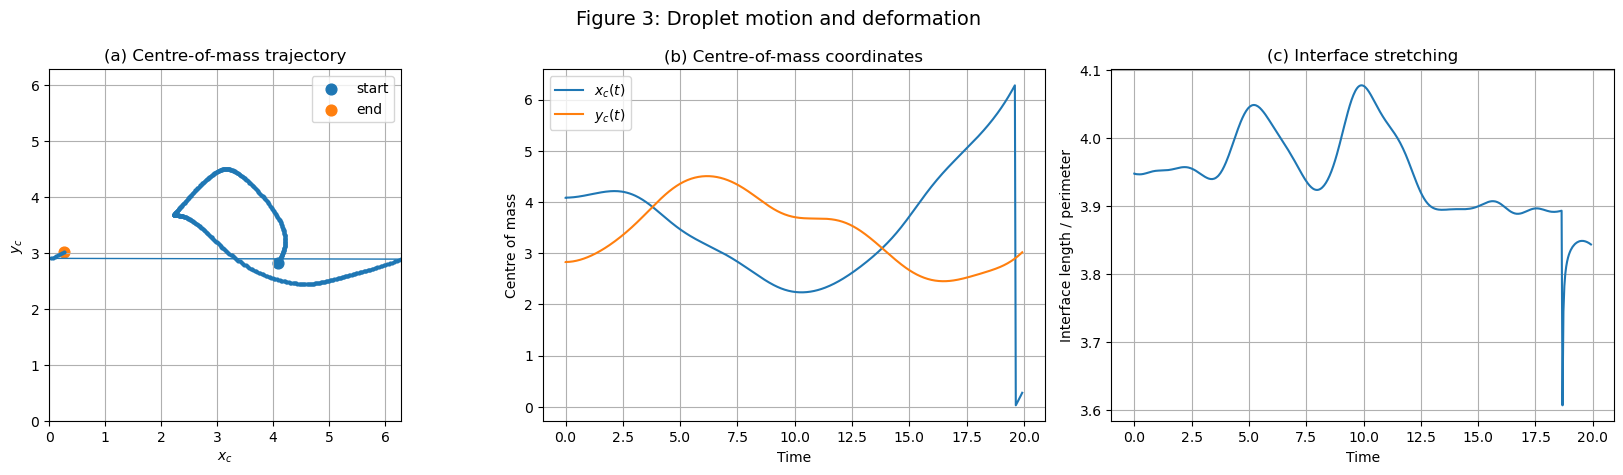

<Figure size 640x480 with 0 Axes>

In [33]:
plot_figure_3_droplet_motion(
    time_history=time_history,
    center_x_history=center_x_history,
    center_y_history=center_y_history,
    L_x=L_x,
    L_y=L_y,
    interface_length_history=interface_length_history
)

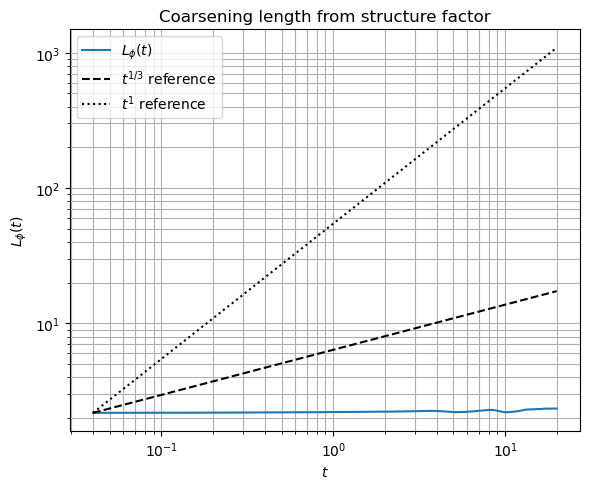

In [34]:
t = np.asarray(track["time"])
L_coarsening = np.asarray(track["L_coarsening"])

# Keep only valid positive-time data
mask = (t > 0) & np.isfinite(L_coarsening) & (L_coarsening > 0)

t_plot = t[mask]
L_plot = L_coarsening[mask]

plt.figure(figsize=(6, 5))

plt.loglog(t_plot, L_plot, label=r"$L_\phi(t)$")

# Choose a reference point away from t=0
ref_index = 0
t0_ref = t_plot[ref_index]
L0_ref = L_plot[ref_index]

# Reference scalings passing through the first valid data point
C13 = L0_ref / (t0_ref**(1.0 / 3.0))
C1 = L0_ref / t0_ref

plt.loglog(
    t_plot,
    C13 * t_plot**(1.0 / 3.0),
    "k--",
    label=r"$t^{1/3}$ reference"
)

plt.loglog(
    t_plot,
    C1 * t_plot,
    "k:",
    label=r"$t^1$ reference"
)

plt.xlabel(r"$t$")
plt.ylabel(r"$L_\phi(t)$")
plt.title("Coarsening length from structure factor")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

Saved phi animation to Results/Experiment_DD_fully_coupled/quiver_plot.gif


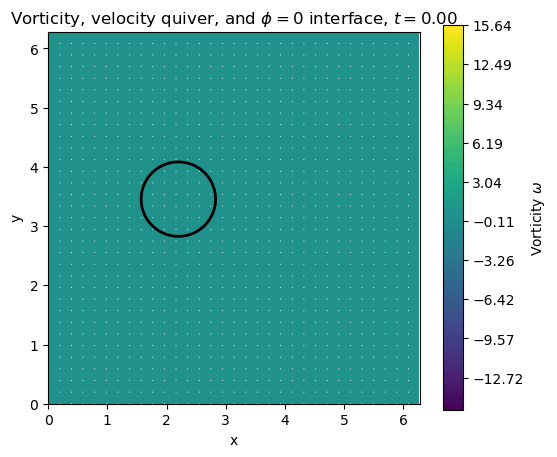

In [35]:
def velocity_from_omega(omega):
    omega_hat = np.fft.fft2(omega)

    psi_hat = np.zeros_like(omega_hat, dtype=complex)
    mask = K2 != 0

    psi_hat[mask] = omega_hat[mask] / K2[mask]
    psi_hat[~mask] = 0.0

    u_x_hat = 1j * Ky * psi_hat
    u_y_hat = -1j * Kx * psi_hat

    u_x = np.fft.ifft2(u_x_hat).real
    u_y = np.fft.ifft2(u_y_hat).real

    return u_x, u_y


fig, ax = plt.subplots(figsize=(6, 5))

skip = 8

omega_min = min(np.min(w) for w in omega_history)
omega_max = max(np.max(w) for w in omega_history)
levels = np.linspace(omega_min, omega_max, 60)

# Initial fields
omega0 = omega_history[0]
phi0 = phi_history[0]
u_x0, u_y0 = velocity_from_omega(omega0)

cont = ax.contourf(X, Y, omega0, levels=levels, cmap="viridis")
cbar = fig.colorbar(cont, ax=ax)
cbar.set_label(r"Vorticity $\omega$")

quiv = ax.quiver(
    X[::skip, ::skip],
    Y[::skip, ::skip],
    u_x0[::skip, ::skip],
    u_y0[::skip, ::skip],
    color="white",
    scale=30,
    width=0.003
)

phi_contour = ax.contour(
    X, Y, phi0,
    levels=[0],
    colors="black",
    linewidths=2
)

ax.set_aspect("equal")
ax.set_xlim(0, L_x)
ax.set_ylim(0, L_y)
ax.set_xlabel("x")
ax.set_ylabel("y")


def update(frame):
    ax.clear()

    omega = omega_history[frame]
    phi = phi_history[frame]
    u_x, u_y = velocity_from_omega(omega)

    ax.contourf(
        X, Y, omega,
        levels=levels,
        cmap="viridis"
    )

    ax.quiver(
        X[::skip, ::skip],
        Y[::skip, ::skip],
        u_x[::skip, ::skip],
        u_y[::skip, ::skip],
        color="white",
        scale=30,
        width=0.003
    )

    ax.contour(
        X, Y, phi,
        levels=[0],
        colors="black",
        linewidths=2
    )

    ax.set_aspect("equal")
    ax.set_xlim(0, L_x)
    ax.set_ylim(0, L_y)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(
        rf"Vorticity, velocity quiver, and $\phi=0$ interface, "
        rf"$t={time_history[frame]:.2f}$"
    )

    return []


anim = animation.FuncAnimation(
    fig,
    update,
    frames=len(omega_history),
    interval=80,
    blit=False
)
output_path = animations_dir / "quiver_plot.gif"
anim.save(output_path, writer="pillow", fps=15)
print(f"Saved phi animation to {output_path}")

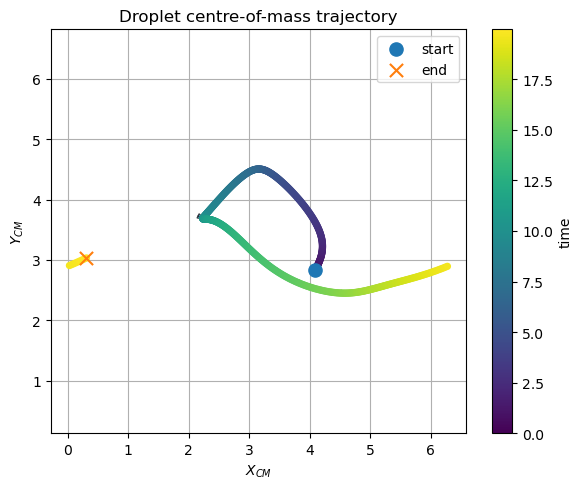

In [36]:
x_cm = np.asarray(track["x_cm"])
y_cm = np.asarray(track["y_cm"])
t = np.asarray(track["time"])

plt.figure(figsize=(6, 5))

sc = plt.scatter(
    x_cm,
    y_cm,
    c=t,
    s=18,
    cmap="viridis",
    zorder=3
)

skip = max(1, len(x_cm) // 30)

for i in range(0, len(x_cm) - skip, skip):
    dx_arrow = x_cm[i + skip] - x_cm[i]
    dy_arrow = y_cm[i + skip] - y_cm[i]

    # Do not draw arrows across periodic jumps
    if abs(dx_arrow) > 0.5 * L_x or abs(dy_arrow) > 0.5 * L_y:
        continue

    plt.arrow(
        x_cm[i],
        y_cm[i],
        dx_arrow,
        dy_arrow,
        length_includes_head=True,
        head_width=0.08,
        head_length=0.12,
        linewidth=0.8,
        alpha=0.7,
        zorder=2
    )

plt.scatter(x_cm[0], y_cm[0], marker="o", s=90, label="start", zorder=4)
plt.scatter(x_cm[-1], y_cm[-1], marker="x", s=90, label="end", zorder=4)

plt.xlabel(r"$X_{CM}$")
plt.ylabel(r"$Y_{CM}$")
plt.title("Droplet centre-of-mass trajectory")
plt.xlim(0, L_x)
plt.ylim(0, L_y)
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.colorbar(sc, label="time")
plt.tight_layout()
plt.show()

In [37]:
def compute_single_trajectory_msd(x_unwrapped, y_unwrapped, t, start_index=0):
    """
    Mean-square displacement from a single CM trajectory.

    M(t) = |r_cm(t) - r_cm(t0)|^2

    Parameters
    ----------
    x_unwrapped, y_unwrapped : arrays
        Unwrapped CM trajectory.
    t : array
        Time array.
    start_index : int
        Index after initial transients.

    Returns
    -------
    tau : array
        Time measured from t0.
    msd : array
        Squared displacement from initial reference point.
    """

    x = np.asarray(x_unwrapped)
    y = np.asarray(y_unwrapped)
    t = np.asarray(t)

    x0 = x[start_index]
    y0 = y[start_index]
    t0 = t[start_index]

    dx = x[start_index:] - x0
    dy = y[start_index:] - y0

    msd = dx**2 + dy**2
    tau = t[start_index:] - t0

    return tau, msd

In [38]:
def unwrap_periodic_trajectory(x, y, Lx, Ly):
    """
    Convert wrapped periodic COM coordinates into continuous unwrapped coordinates.
    """

    x = np.asarray(x)
    y = np.asarray(y)

    x_unwrapped = np.empty_like(x, dtype=float)
    y_unwrapped = np.empty_like(y, dtype=float)

    x_unwrapped[0] = x[0]
    y_unwrapped[0] = y[0]

    for n in range(1, len(x)):
        dx = x[n] - x[n - 1]
        dy = y[n] - y[n - 1]

        if dx > 0.5 * Lx:
            dx -= Lx
        elif dx < -0.5 * Lx:
            dx += Lx

        if dy > 0.5 * Ly:
            dy -= Ly
        elif dy < -0.5 * Ly:
            dy += Ly

        x_unwrapped[n] = x_unwrapped[n - 1] + dx
        y_unwrapped[n] = y_unwrapped[n - 1] + dy

    return x_unwrapped, y_unwrapped

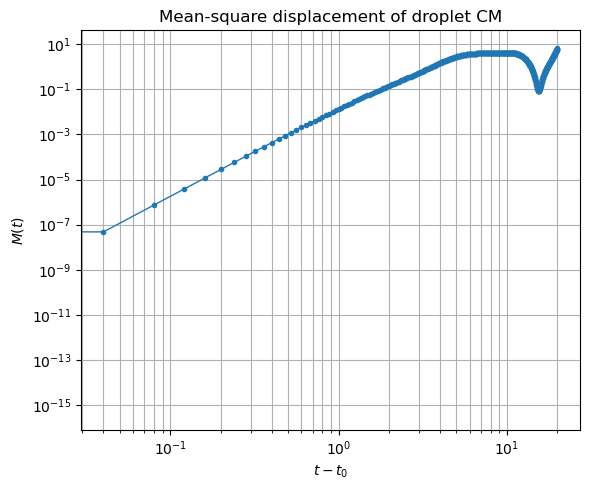

In [39]:
x_cm = np.asarray(track["x_cm"])
y_cm = np.asarray(track["y_cm"])
t_cm = np.asarray(track["time"])

x_unwrapped, y_unwrapped = unwrap_periodic_trajectory(
    x_cm,
    y_cm,
    L_x,
    L_y
)

start_index = 0

tau, msd = compute_single_trajectory_msd(
    x_unwrapped,
    y_unwrapped,
    t_cm,
    start_index=start_index
)

plt.figure(figsize=(6, 5))
plt.loglog(tau[1:], msd[1:], marker="o", markersize=3, linewidth=1)

plt.xlabel(r"$t-t_0$")
plt.ylabel(r"$M(t)$")
plt.title("Mean-square displacement of droplet CM")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

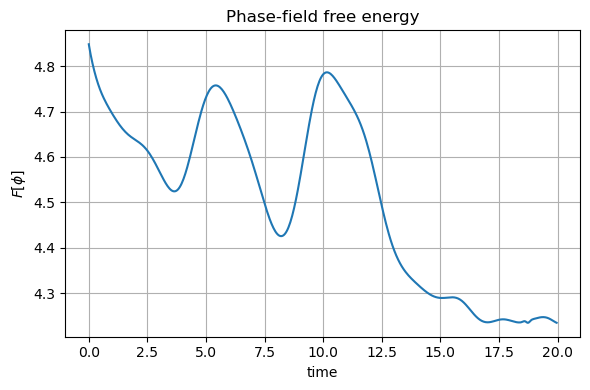

In [40]:
plt.figure(figsize=(6, 4))
plt.plot(track["time"], track["free_energy"])
plt.xlabel("time")
plt.ylabel(r"$F[\phi]$")
plt.title("Phase-field free energy")
plt.grid(True)
plt.tight_layout()
plt.show()

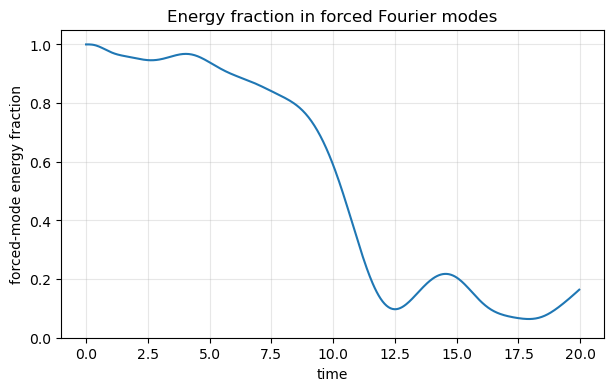

In [41]:
def get_wavenumber_grids(Nx, Ny, Lx, Ly):
    """
    Return Fourier wavenumber grids KX, KY and radial wavenumber K.
    """

    kx = 2 * np.pi * np.fft.fftfreq(Nx, d=Lx / Nx)
    ky = 2 * np.pi * np.fft.fftfreq(Ny, d=Ly / Ny)

    KX, KY = np.meshgrid(kx, ky, indexing="ij")
    K = np.sqrt(KX**2 + KY**2)

    return KX, KY, K

def compute_forced_mode_fraction_vorticity(
    omega_history,
    Lx,
    Ly,
    kf,
    tolerance=1e-12
):
    """
    Compute forced-mode energy fraction from vorticity fields.

    Uses |u_hat(k)|^2 = |omega_hat(k)|^2 / k^2 for k != 0.
    """

    nt, Nx, Ny = np.asarray(omega_history).shape

    K_X, K_Y, K = get_wavenumber_grids(Nx, Ny, Lx, Ly)

    K2 = K**2
    nonzero_mask = K2 > 0

    forced_mask = np.isclose(K, kf, atol=tolerance)

    forced_fraction = []

    for omega in omega_history:
        omega_hat = np.fft.fft2(omega)

        spectral_energy = np.zeros_like(K, dtype=float)
        spectral_energy[nonzero_mask] = 0.5 * (np.abs(omega_hat[nonzero_mask])**2 / K2[nonzero_mask])

        total_energy = np.sum(spectral_energy)
        forced_energy = np.sum(spectral_energy[forced_mask])

        if total_energy > 0:
            forced_fraction.append(forced_energy / total_energy)
        else:
            forced_fraction.append(np.nan)

    return np.array(forced_fraction)

def plot_forced_mode_fraction(time_history, forced_fraction):
    """
    Plot forced-mode energy fraction over time.
    """

    plt.figure(figsize=(7, 4))
    plt.plot(time_history, forced_fraction)
    plt.xlabel("time")
    plt.ylabel("forced-mode energy fraction")
    plt.title("Energy fraction in forced Fourier modes")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.show()

forced_fraction = compute_forced_mode_fraction_vorticity(
    omega_history,
    Lx=L_x,
    Ly=L_y,
    kf=k_f
)

plot_forced_mode_fraction(time_history, forced_fraction)

[0, 167, 334, 500]


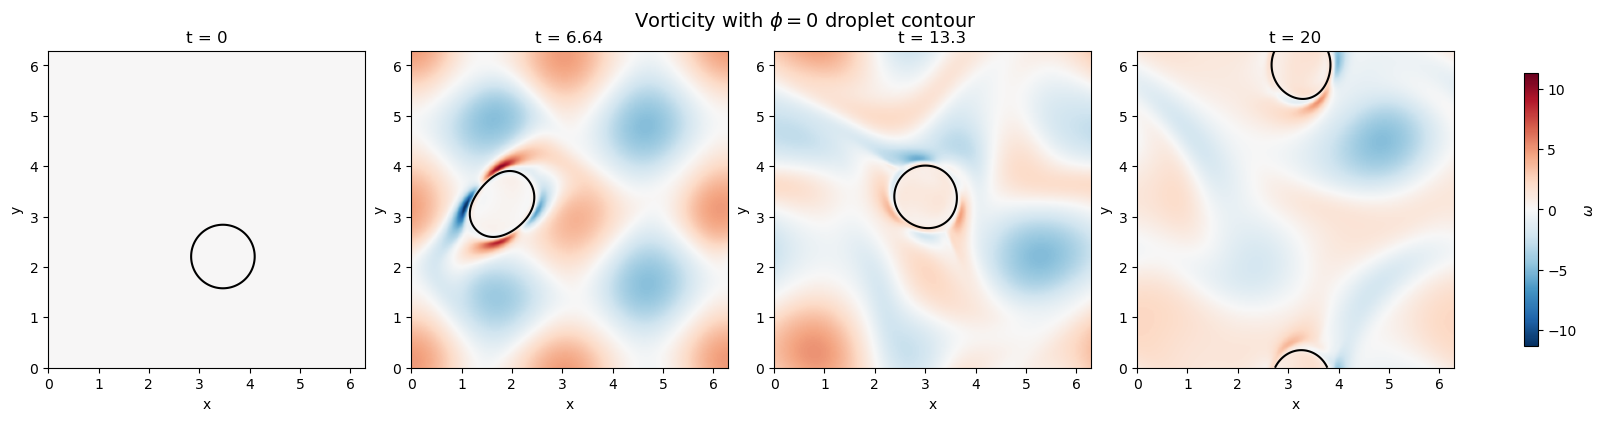

In [42]:
def plot_vorticity_contour_snapshots(
    omega_history,
    phi_history,
    time_history,
    Lx,
    Ly,
    indices=None,
    omega_vlim=None,
    contour_level=0.0,
    cmap="RdBu_r",
    figsize=(16, 4),
):
    """
    Plot vorticity snapshots with phi=0 droplet contour overlaid.
    """
    omega_history = np.asarray(omega_history)
    nt = len(omega_history)

    if indices is None:
        indices = [0, nt // 3, 2 * nt // 3, nt - 1]

    indices = list(dict.fromkeys(indices))
    print(indices)

    extent = (0, Lx, 0, Ly)

    if omega_vlim is None:
        omega_vlim = np.nanmax(np.abs(omega_history[indices]))

    fig, axes = plt.subplots(1, len(indices), figsize=figsize, constrained_layout=True)

    if len(indices) == 1:
        axes = [axes]

    im = None

    for ax, idx in zip(axes, indices):
        im = ax.imshow(
            omega_history[idx].T,
            origin="lower",
            extent=extent,
            cmap=cmap,
            vmin=-omega_vlim,
            vmax=omega_vlim,
            aspect="equal",
        )

        ax.contour(
            phi_history[idx].T,
            levels=[contour_level],
            colors="black",
            linewidths=1.5,
            extent=extent,
        )

        ax.set_title(f"t = {time_history[idx]:.3g}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    fig.colorbar(im, ax=axes, shrink=0.85, label=r"$\omega$")
    fig.suptitle(r"Vorticity with $\phi=0$ droplet contour", fontsize=14)
    plt.show()

plot_vorticity_contour_snapshots(
    omega_history,
    phi_history,
    time_history,
    Lx=L_x,
    Ly=L_y,
)

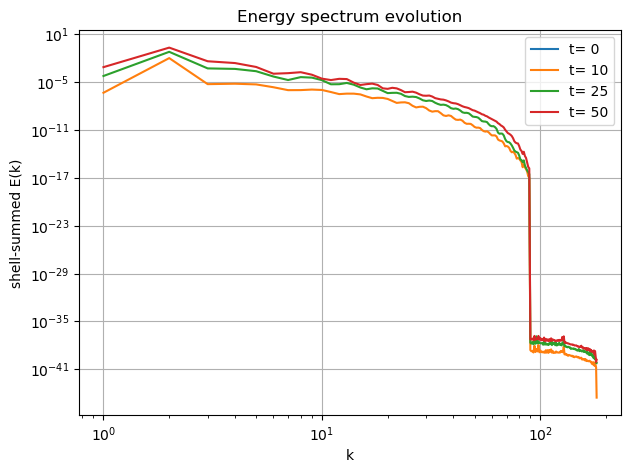

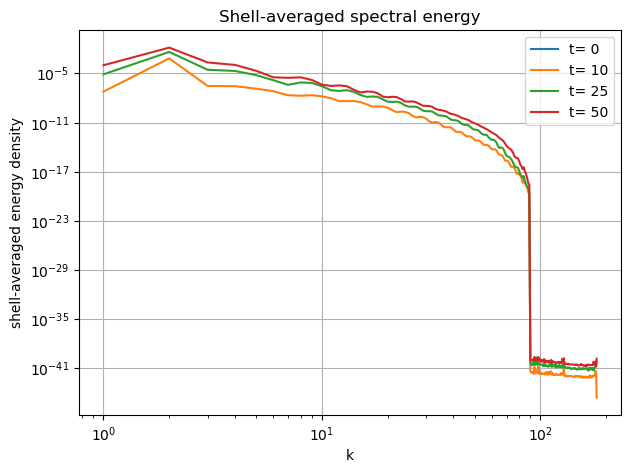

In [43]:
def compute_energy_spectrum(omega_hat, Kx, Ky, N_x, N_y):
    K2 = Kx**2 + Ky**2
    Kmag = np.sqrt(K2)

    K2_nozero = K2.copy()
    K2_nozero[0, 0] = 1.0

    energy_density = np.abs(omega_hat)**2 / K2_nozero
    energy_density /= (N_x * N_y)**2
    energy_density[0, 0] = 0.0

    k_bins = np.floor(Kmag).astype(int)
    kmax = k_bins.max()

    E_sum = np.zeros(kmax + 1)
    E_avg = np.zeros(kmax + 1)
    counts = np.zeros(kmax + 1)

    for k in range(kmax + 1):
        mask = (k_bins == k)
        counts[k] = np.sum(mask)

        if counts[k] > 0:
            E_sum[k] = np.sum(energy_density[mask])
            E_avg[k] = E_sum[k] / counts[k]

    return np.arange(kmax + 1), E_sum, E_avg, counts

times_to_plot = [0, 10, 25, 50]

omega_history = np.asarray(omega_history)

plt.figure(figsize=(7, 5))

for idx in times_to_plot:
    omega = omega_history[idx]
    omega_hat = np.fft.fft2(omega)

    k_vals, E_sum, E_avg, counts = compute_energy_spectrum(
        omega_hat, Kx, Ky, N_x, N_y
    )

    plt.loglog(k_vals[1:], E_sum[1:], label=f"t= {idx}")

plt.xlabel("k")
plt.ylabel("shell-summed E(k)")
plt.title("Energy spectrum evolution")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))

for idx in times_to_plot:
    omega = omega_history[idx]
    omega_hat = np.fft.fft2(omega)

    k_vals, E_sum, E_avg, counts = compute_energy_spectrum(
        omega_hat, Kx, Ky, N_x, N_y
    )

    plt.loglog(k_vals[1:], E_avg[1:], label=f"t= {idx}")

plt.xlabel("k")
plt.ylabel("shell-averaged energy density")
plt.title("Shell-averaged spectral energy")
plt.legend()
plt.grid(True)
plt.show()